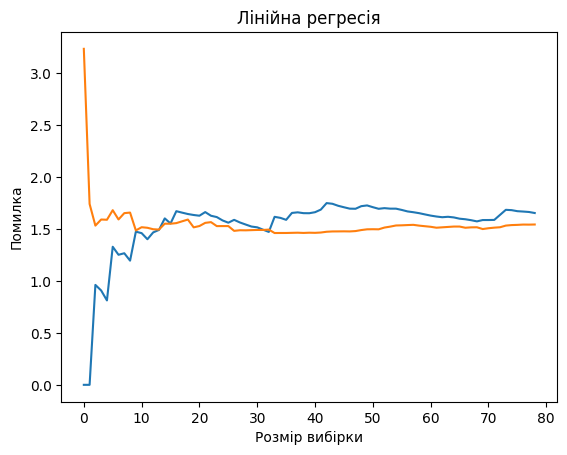

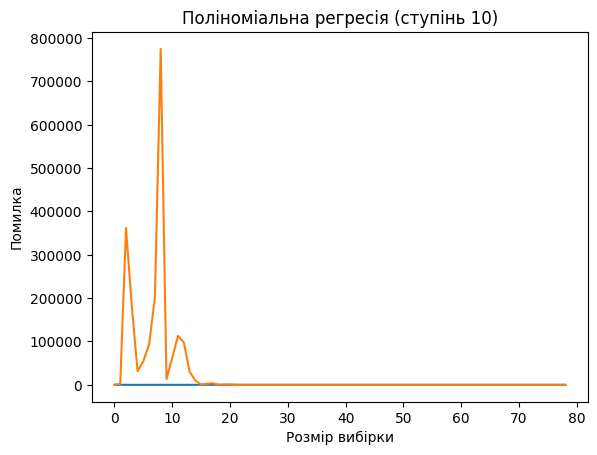

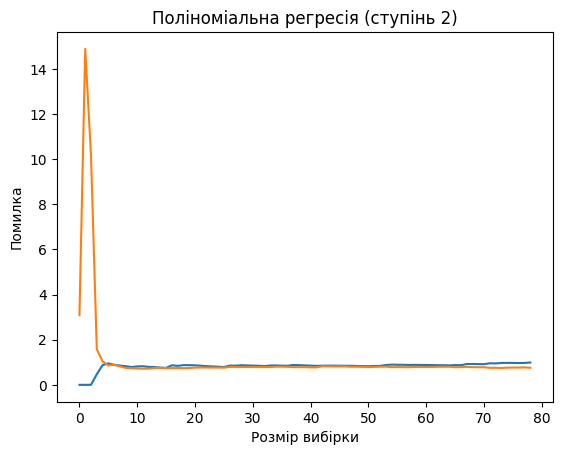

In [3]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

m = 100
X = 6 * np.random.rand(m, 1) - 5
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

y = y.ravel()

def plot_learning_curves(model, X, y, title):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []

    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_val_pred = model.predict(X_val)

        train_errors.append(mean_squared_error(y_train[:m], y_train_pred))
        val_errors.append(mean_squared_error(y_val, y_val_pred))

    plt.figure()
    plt.plot(np.sqrt(train_errors))
    plt.plot(np.sqrt(val_errors))
    plt.xlabel("Розмір вибірки")
    plt.ylabel("Помилка")
    plt.title(title)
    plt.show()

# 1. Лінійна
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y, "Лінійна регресія")

# 2. Поліном 10
poly10 = Pipeline([
    ("poly", PolynomialFeatures(degree=10, include_bias=False)),
    ("lin", LinearRegression())
])
plot_learning_curves(poly10, X, y, "Поліноміальна регресія (ступінь 10)")

# 3. Поліном 2
poly2 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lin", LinearRegression())
])
plot_learning_curves(poly2, X, y, "Поліноміальна регресія (ступінь 2)")